In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [3]:
df = pd.read_csv("concrete_data.csv")

In [4]:
df.head(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
df.shape

(1030, 9)

In [6]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [8]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [9]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [10]:
X_train , X_test , y_train , y_test = train_test_split(X,y,random_state = 42,test_size=0.2)

In [11]:
X

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


In [12]:
X_train.shape

(824, 8)

In [13]:
X_test.shape

(206, 8)

In [14]:
y_train.shape

(824,)

In [15]:
y_test.shape

(206,)

The R² score (also called the coefficient of determination) is a metric used to evaluate the performance of a regression model. It tells you how well the model’s predictions match the actual data.

In [16]:
# applying linear regression without any transformation
lin_reg = LinearRegression()
lin_reg.fit(X_train ,y_train)
y_pred = lin_reg.predict(X_test)
r2_score(y_test , y_pred)

0.627553179231485

In [17]:
df.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
842,151.0,0.0,184.0,167.0,12.0,991.0,772.0,28,15.57
1015,322.5,148.6,0.0,185.8,8.5,951.0,709.5,28,52.43
1004,279.8,128.9,100.4,172.4,9.5,825.1,804.9,28,52.83
69,485.0,0.0,0.0,146.0,0.0,1120.0,800.0,28,71.99
622,307.0,0.0,0.0,193.0,0.0,968.0,812.0,365,36.15


C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\286431162.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


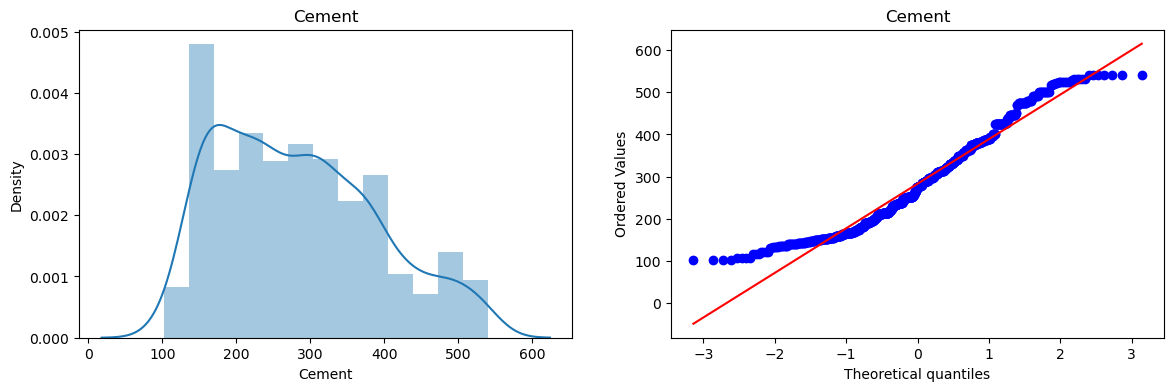

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\286431162.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


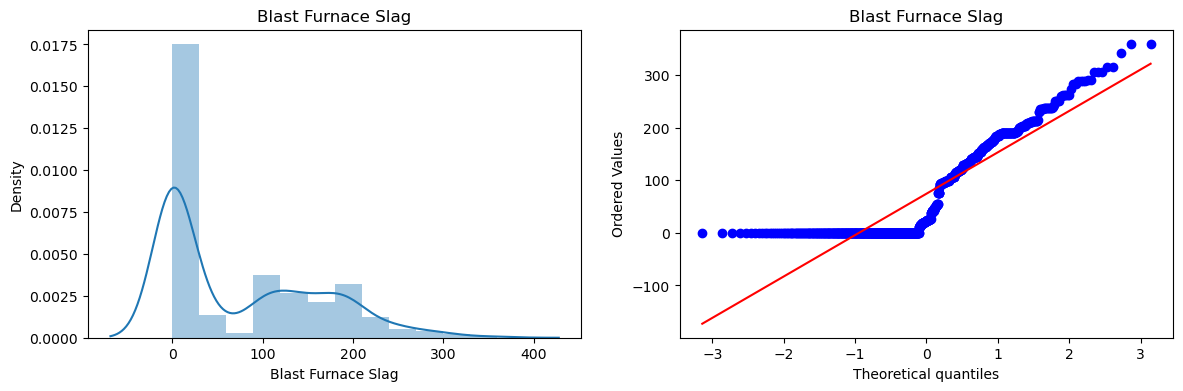

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\286431162.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


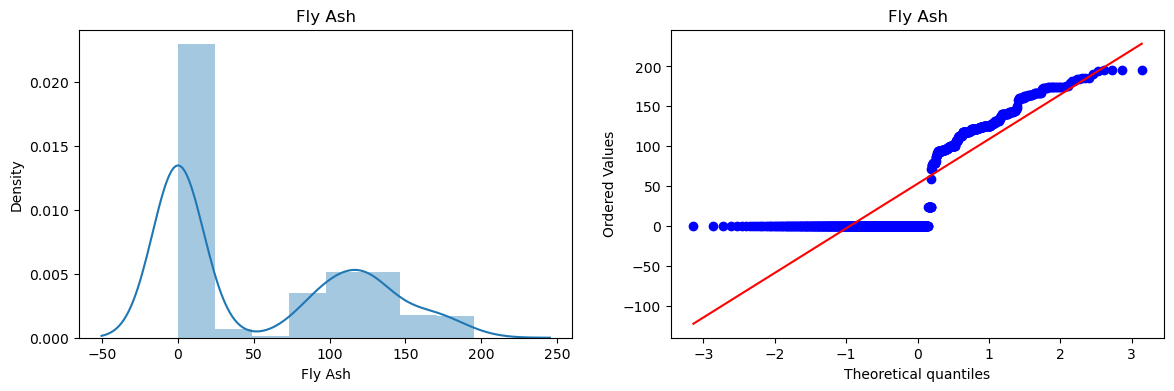

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\286431162.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


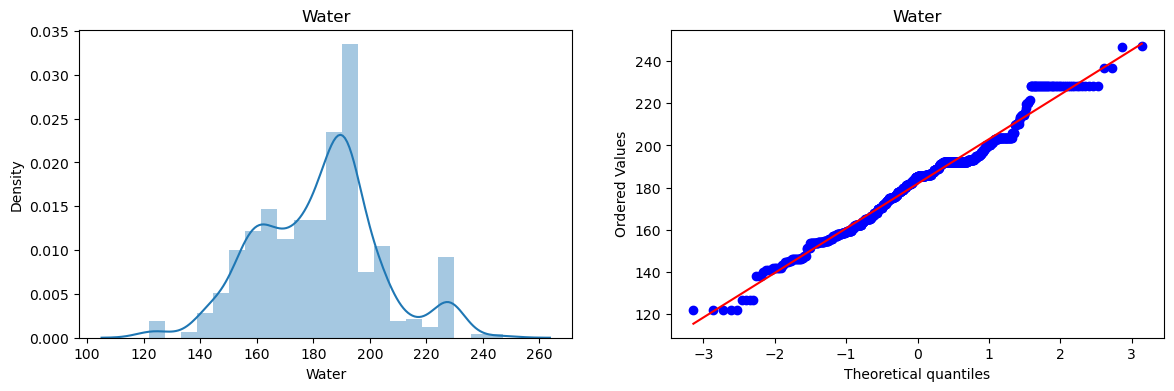

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\286431162.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


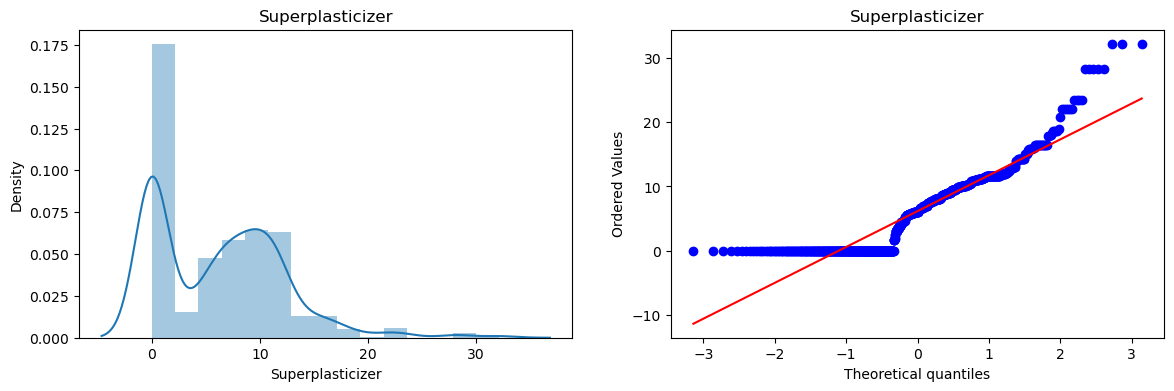

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\286431162.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


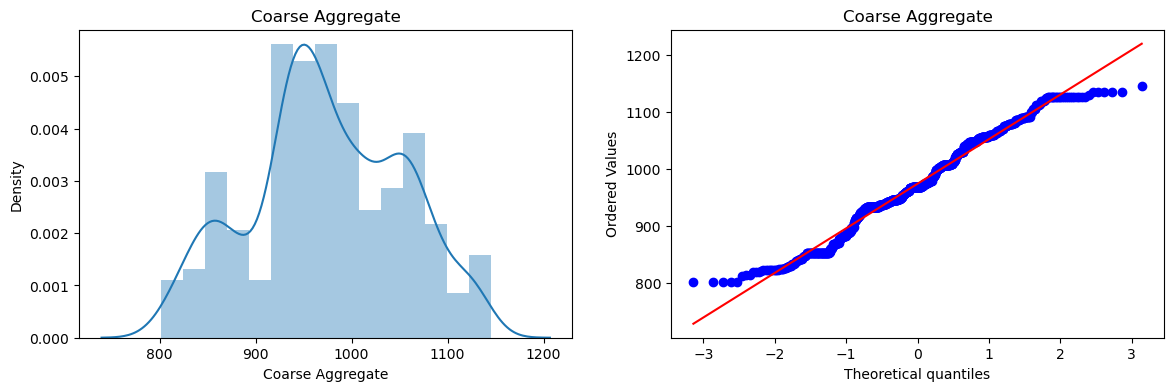

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\286431162.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


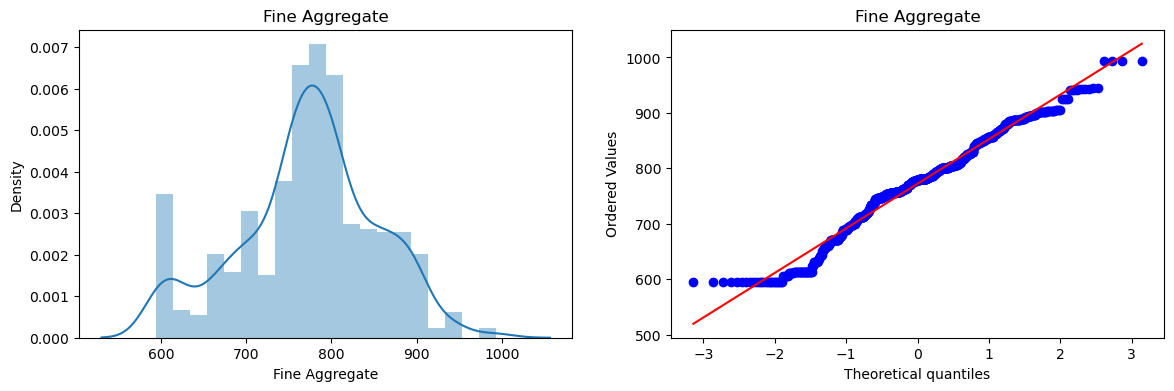

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\286431162.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


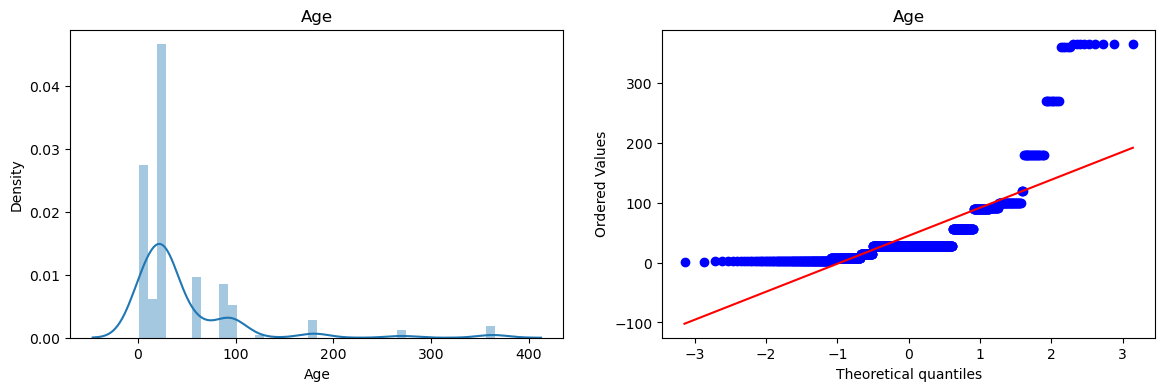

In [18]:
#Plotting the distplots without any transformations 

for col in X_train.columns:
    plt.figure(figsize =(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col] , dist = "norm" , plot = plt)
    plt.title(col)

    plt.show()

### applying box cox transform 

In [19]:
pt = PowerTransformer(method='box-cox')
pt_X_train = pt.fit_transform(X_train + 0.0000001)
pt_X_test = pt.transform(X_test + 0.0000001)

In [20]:
pt_X_train

array([[-1.27975148,  0.952465  ,  1.12792184, ..., -0.26250009,
        -0.67756847,  0.10600969],
       [ 1.24470596,  0.72494984,  1.13640769, ..., -1.91272789,
        -0.3140622 ,  0.10600969],
       [ 0.07984236, -1.08630996,  1.13091439, ...,  1.01840672,
         0.02595743, -1.67597002],
       ...,
       [-0.84451727, -1.08630996,  1.13293882, ...,  1.34536666,
         0.29715693,  1.24673335],
       [ 1.56562351,  0.92507694, -0.88724442, ..., -1.53725479,
         0.0762111 ,  0.10600969],
       [ 0.42655631, -1.08630996,  1.12619639, ..., -0.62083415,
         0.09510819,  0.10600969]])

In [21]:
pt_X_train = pd.DataFrame(pt_X_train, columns=X_train.columns)
pt_X_test = pd.DataFrame(pt_X_test, columns=X_test.columns)

λ (lambda) defines how much transformation is applied to each feature.

In [22]:
lambda_df = pd.DataFrame({
    'cols': X_train.columns,
    'box_cox_lambdas': pt.lambdas_
})

In [23]:
lambda_df

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.022767
2,Fly Ash,-0.034635
3,Water,0.772682
4,Superplasticizer,0.087141
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [24]:
#applying linear regression on transformed data

lr = LinearRegression()

lr.fit(pt_X_train , y_train)
y_pred2 = lr.predict(pt_X_test)

r2_score(y_test , y_pred2)

0.8042534512206333

In [27]:
X_train

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
995,158.6,148.9,116.0,175.1,15.0,953.3,719.7,28
507,424.0,22.0,132.0,178.0,8.5,822.0,750.0,28
334,275.1,0.0,121.4,159.5,9.9,1053.6,777.5,3
848,252.0,97.0,76.0,194.0,8.0,835.0,821.0,28
294,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,3
...,...,...,...,...,...,...,...,...
87,286.3,200.9,0.0,144.7,11.2,1004.6,803.7,3
330,246.8,0.0,125.1,143.3,12.0,1086.8,800.9,14
466,190.3,0.0,125.2,166.6,9.9,1079.0,798.9,100
121,475.0,118.8,0.0,181.1,8.9,852.1,781.5,28


In [25]:
pt_X_train

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,-1.279751,0.952465,1.127922,-0.301920,0.882668,-0.262500,-0.677568,0.106010
1,1.244706,0.724950,1.136408,-0.165055,0.751714,-1.912728,-0.314062,0.106010
2,0.079842,-1.086310,1.130914,-1.047291,0.786233,1.018407,0.025957,-1.675970
3,-0.145641,0.900610,1.099884,0.581224,0.738115,-1.750779,0.583253,0.106010
4,-1.131044,0.801340,1.132465,-1.105297,0.806139,1.368575,0.262623,-1.675970
...,...,...,...,...,...,...,...,...
819,0.183601,0.989009,-0.887244,-1.769923,0.814504,0.390563,0.358776,-1.675970
820,-0.198733,-1.086310,1.132886,-1.839129,0.830446,1.445973,0.322797,-0.475625
821,-0.844517,-1.086310,1.132939,-0.706089,0.786233,1.345367,0.297157,1.246733
822,1.565624,0.925077,-0.887244,-0.019311,0.762077,-1.537255,0.076211,0.106010


C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pt_X_train[col])


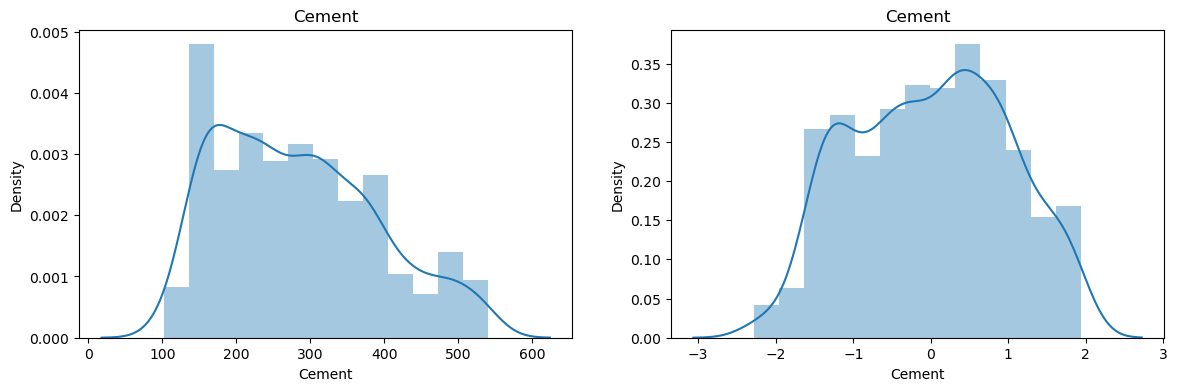

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pt_X_train[col])


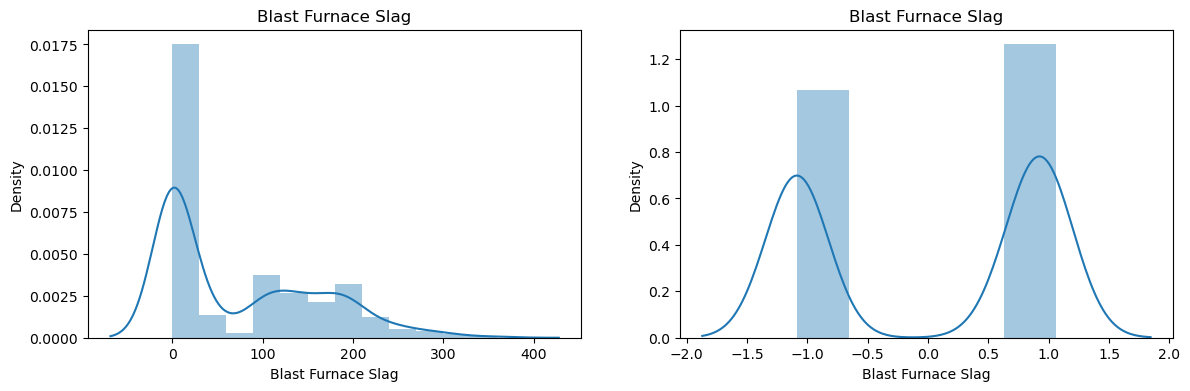

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pt_X_train[col])


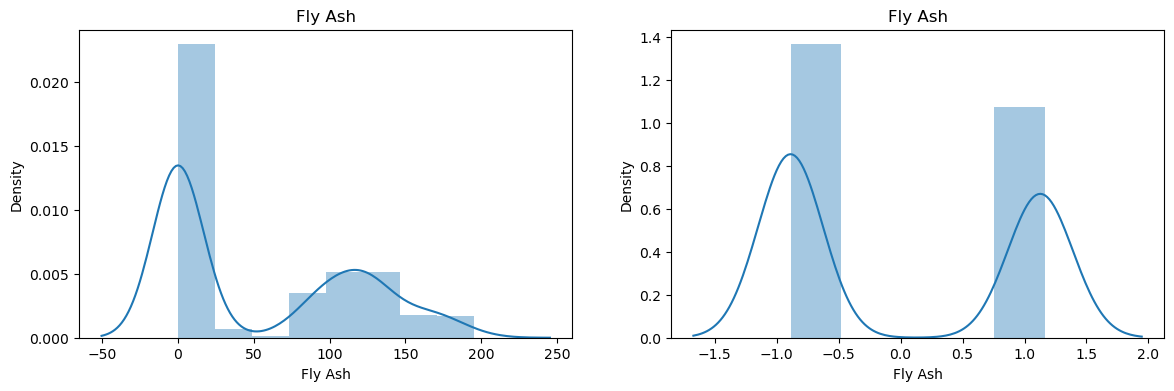

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pt_X_train[col])


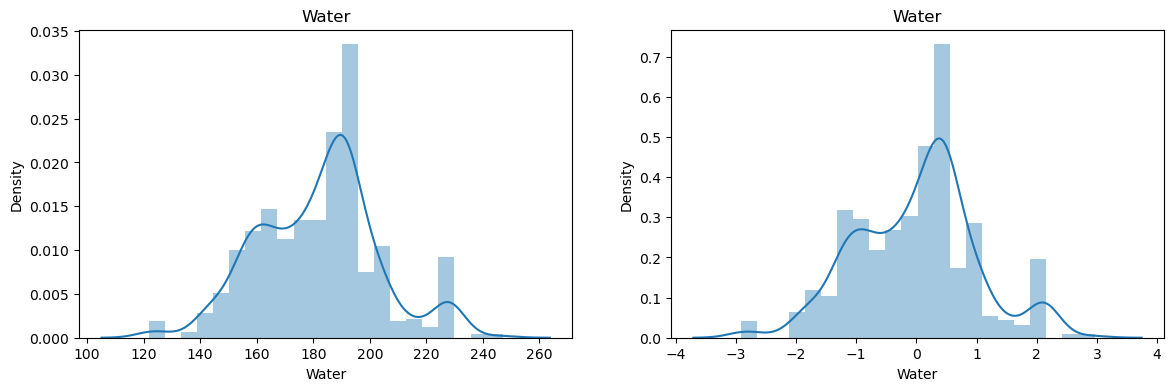

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pt_X_train[col])


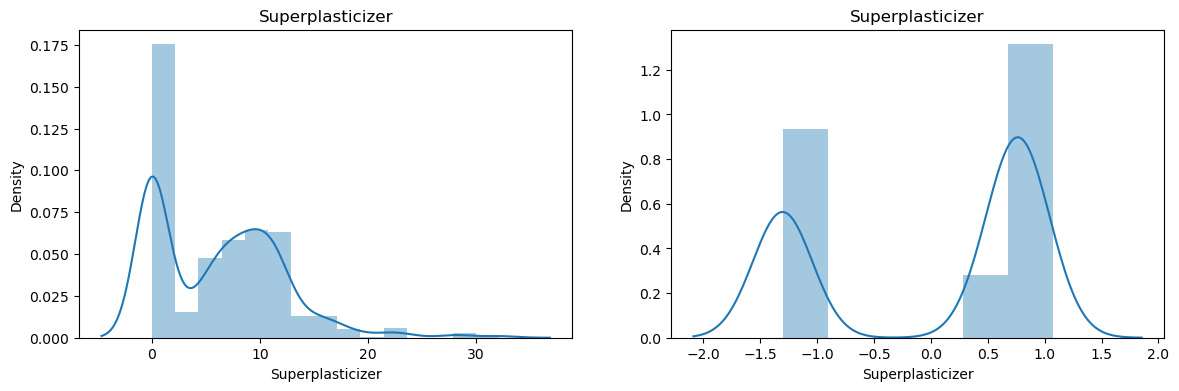

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pt_X_train[col])


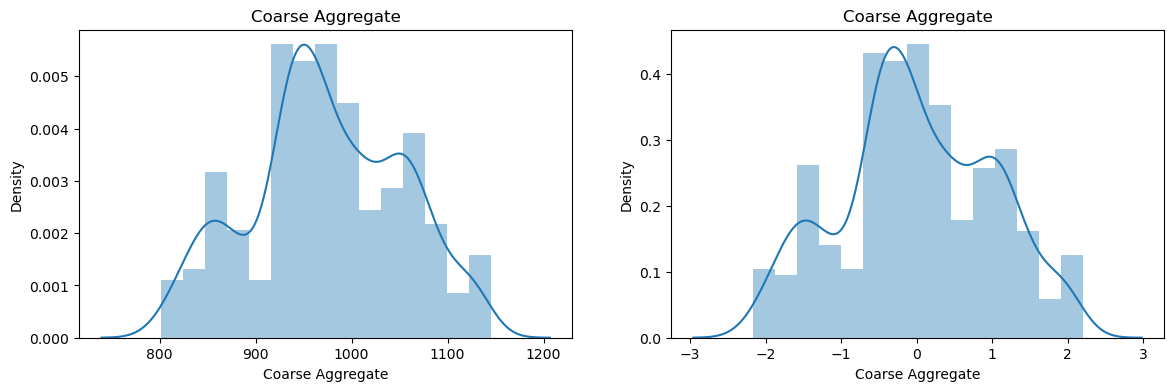

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pt_X_train[col])


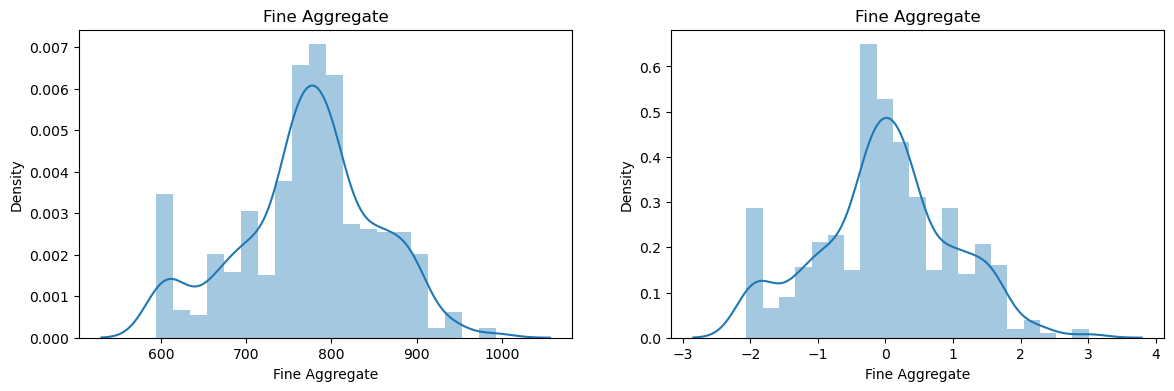

C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\swaya\AppData\Local\Temp\ipykernel_20440\265037104.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pt_X_train[col])


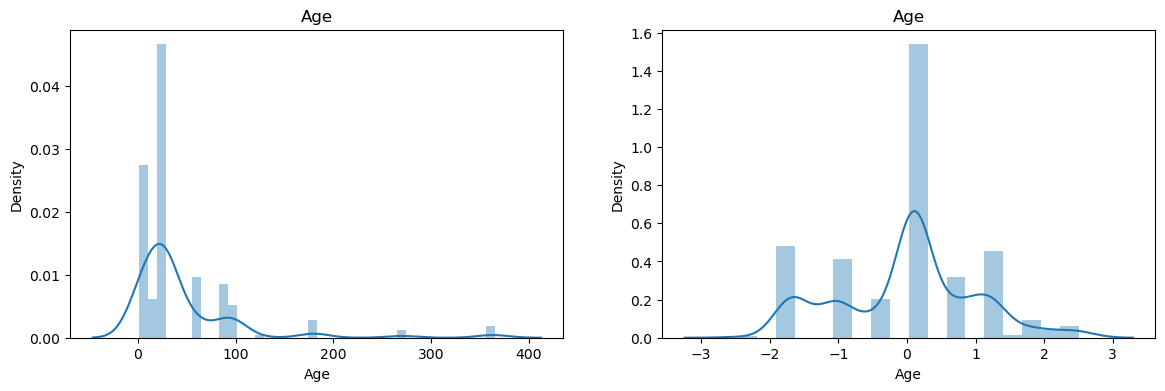

In [28]:
# before and after comparision for box cox plot 

for col in pt_X_train.columns:
    plt.figure(figsize=(14 , 4))
    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.distplot(pt_X_train[col])
    plt.title(col)

    plt.show()

### YEO - JOHNSON

In [29]:
pt1 = PowerTransformer(method='yeo-johnson')
pt1_X_train = pt1.fit_transform(X_train)
pt1_X_test = pt1.transform(X_test)


In [43]:
lr = LinearRegression()
lr.fit(pt1_X_train , y_train)
y_pred2 = lr.predict(pt1_X_test)
r2_score(y_test , y_pred2)

0.8161906513354854

In [30]:
pt1_X_train

array([[-1.2797506 ,  1.0181684 ,  1.13099335, ..., -0.26250397,
        -0.67756699,  0.10577763],
       [ 1.2448127 ,  0.22258409,  1.16667068, ..., -1.91271708,
        -0.3140633 ,  0.10577763],
       [ 0.07975145, -1.05692806,  1.14363683, ...,  1.01840694,
         0.02595441, -1.664976  ],
       ...,
       [-0.84466055, -1.05692806,  1.15215184, ...,  1.34537013,
         0.29715299,  1.25751143],
       [ 1.56574084,  0.92179625, -0.88493182, ..., -1.53724924,
         0.07620785,  0.10577763],
       [ 0.42653433, -1.05692806,  1.12367271, ..., -0.62083672,
         0.09510487,  0.10577763]])

In [31]:
pt1_X_train = pd.DataFrame(pt1_X_train , columns=X_train.columns)
pt1_X_test = pd.DataFrame(pt1_X_test , columns= X_test.columns)

In [32]:
pt1_X_test

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,-0.007160,0.904251,-0.884932,2.122555,-1.221863,-0.532334,-1.248261,2.476216
1,0.813196,1.120462,-0.884932,-0.787483,0.962512,-0.371545,-0.243148,-1.053312
2,1.011999,1.120462,-0.884932,-1.710739,1.722620,-0.371545,-0.243148,0.105778
3,0.813196,1.120462,-0.884932,-0.787483,0.962512,-0.371545,-0.243148,-1.664976
4,-1.488654,-1.056928,1.248029,0.949079,0.585508,-1.887824,1.225558,0.105778
...,...,...,...,...,...,...,...,...
201,1.386951,0.257478,1.020733,-0.926769,0.962512,-0.088536,-0.768070,0.725947
202,-0.115544,-1.056928,-0.884932,0.488735,-1.221863,-1.064549,2.300432,0.105778
203,0.183530,1.146737,-0.884932,-1.769937,0.924953,0.390560,0.358772,-1.053312
204,1.244813,0.222584,1.166671,-0.639204,0.689050,-1.912717,-0.314063,0.725947


In [35]:
lambdas_df1 =pd.DataFrame({
    'cols' : X_train.columns,
    'Yeo-Johnson-lambdas' : pt1.lambdas_
    
})

In [36]:
lambdas_df1

,cols,Yeo-Johnson-lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


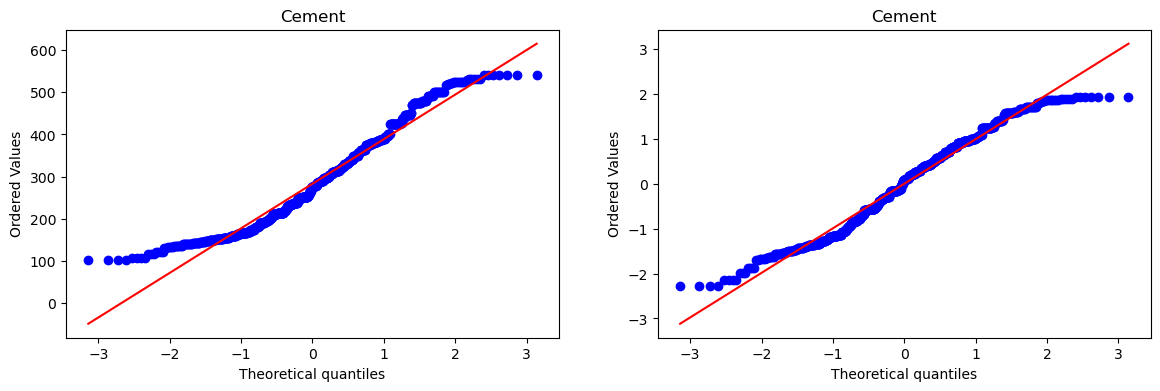

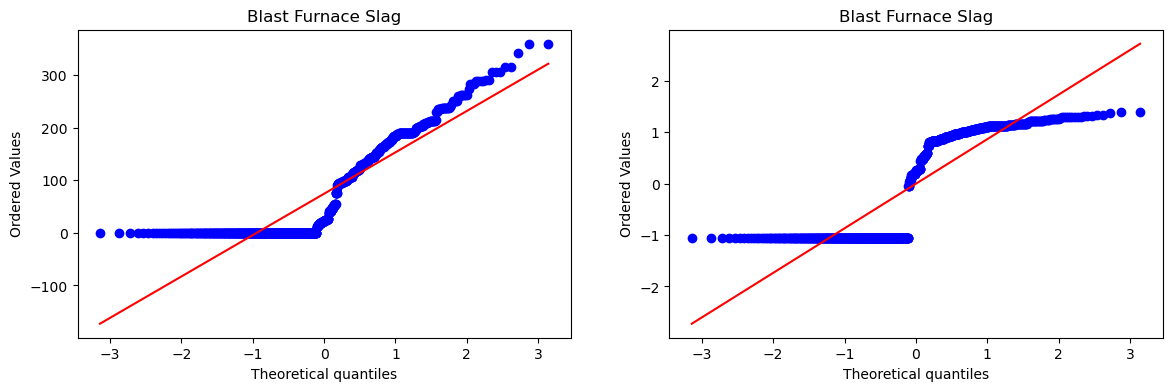

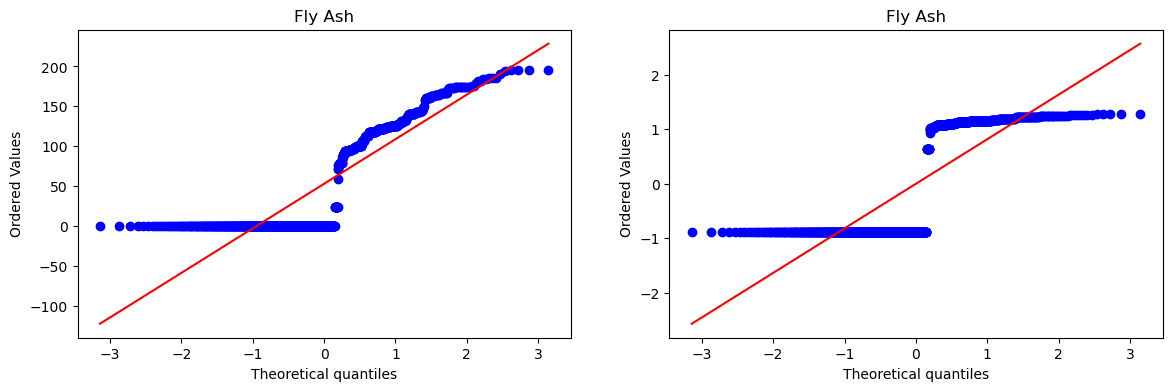

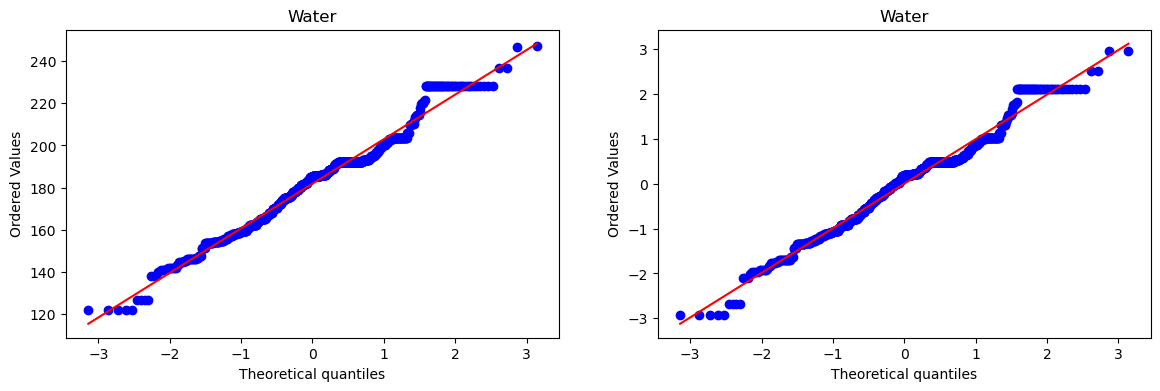

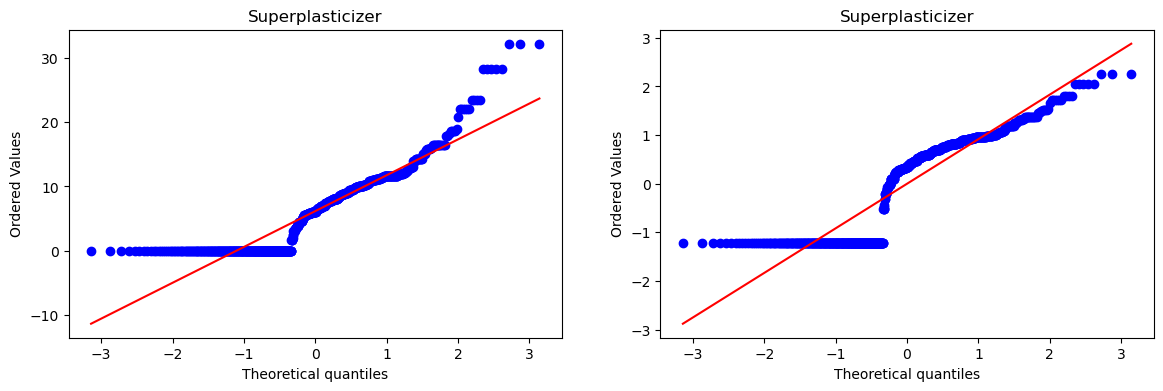

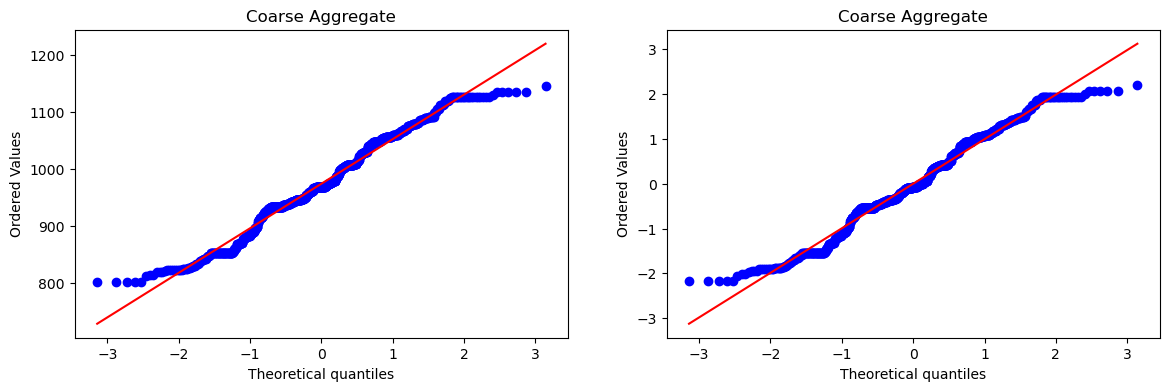

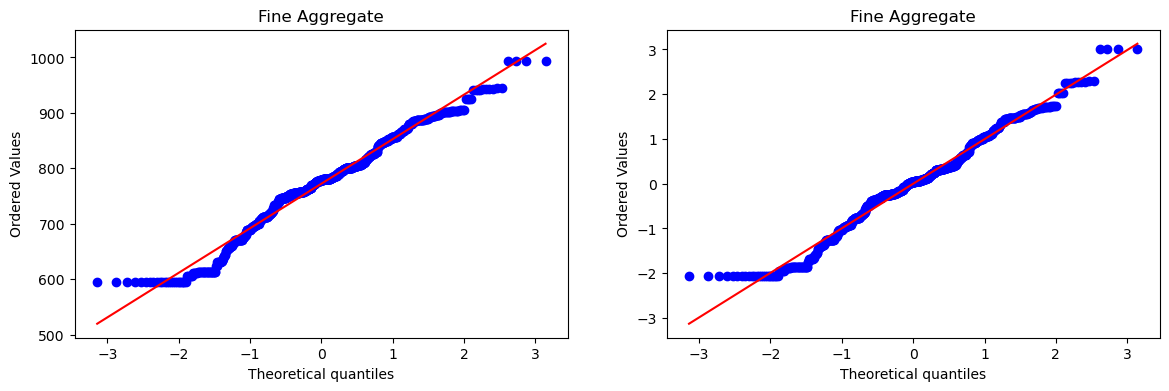

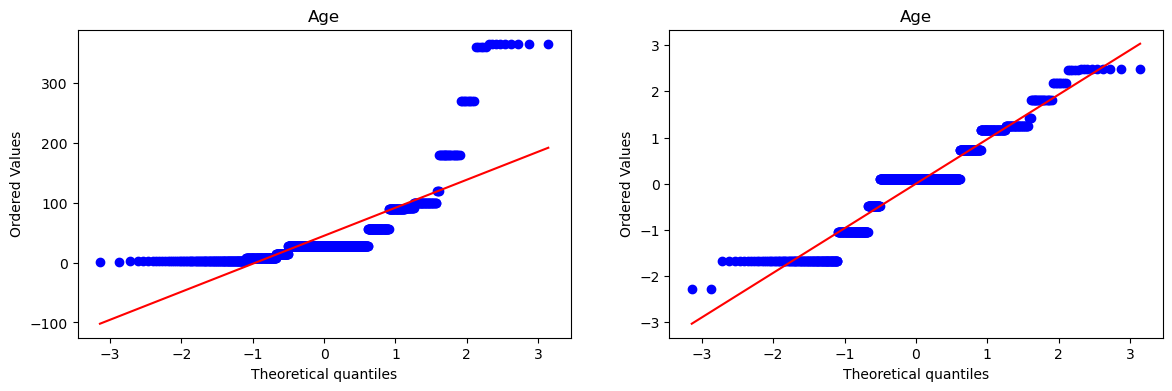

In [42]:
for col in pt1_X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    stats.probplot(X_train[col] , dist = 'norm' , plot = plt)
    plt.title(col)

    plt.subplot(1,2,2)
    stats.probplot(pt1_X_train[col] , dist = 'norm' , plot = plt)
    plt.title(col)
    plt.show()

In [46]:
# comparing box-cox and yeo-johnson
pd.DataFrame({
    'cols' :X_train.columns,
    'box_cox_lamdas'  : pt.lambdas_,
    'Yeo-johnson_lamdas' : pt1.lambdas_ 
})

,cols,box_cox_lamdas,Yeo-johnson_lamdas
0,Cement,0.177025,0.174348
1,Blast Furnace Slag,0.022767,0.015715
2,Fly Ash,-0.034635,-0.161447
3,Water,0.772682,0.771307
4,Superplasticizer,0.087141,0.253935
5,Coarse Aggregate,1.129813,1.130050
6,Fine Aggregate,1.782018,1.783100
7,Age,0.066631,0.019885
